## Exploratory Data Analysis on the raw data

In [1]:
# Import all the desired packages and libraries
import os

import json
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Image

import warnings
warnings.filterwarnings("ignore")


- Load raw data from local directory

In [5]:
DATA_DIR = "EPL_2025"

def load_match_data(data_path: str = DATA_DIR):
    unique_teams = set()
    match_data = []
    shots_data = []

    for dirpath, dirnames, filenames in os.walk(data_path):
        if "context.json" in filenames and "shots.json" in filenames:
            try:
                with open(os.path.join(dirpath, "context.json"), "r") as f:
                    context = json.load(f)
                with open(os.path.join(dirpath, "shots.json"), "r") as f:
                    shots = json.load(f)
                
                # Extract relevant data from context and shots files
                home_team = context.get("team_h")
                away_team = context.get("team_a")

                
                match_data.append({
                    "match_id": context.get("id"),
                    "home_team": home_team,
                    "away_team": away_team,
                    "h_goals": int(context.get("h_goals")),
                    "a_goals": int(context.get("a_goals")),
                    "h_shot": int(context.get("h_shot")),
                    "a_shot": int(context.get("a_shot")),
                    "h_xg": float(context.get("h_xg")),
                    "a_xg": float(context.get("a_xg")),
                    "h_shotOnTarget": int(context.get("h_shotOnTarget")),
                    "a_shotOnTarget": int(context.get("a_shotOnTarget")),
                    "h_ppda": float(context.get("h_ppda")),
                    "a_ppda": float(context.get("a_ppda")),
                    # "h_shots": home_shots,
                    # "a_shots": away_shots
                })

                for shot in shots.get("h", []):
                    shots_data.append({
                        "match_id": shot.get("match_id"),
                        "team": home_team,
                        "opponent": away_team,
                        "minute": int(shot.get("minute")),
                        "result": shot.get("result"),
                        "xG": float(shot.get("xG")),
                        "player": shot.get("player"),
                        "h_a": shot.get("h_a"),
                        "h_goals": int(context.get("h_goals")),
                        "a_goals": int(context.get("a_goals")),
                        "shotType": shot.get("shotType"),
                        "situation": shot.get("situation")
                        })
                for shot in shots.get("a", []):
                    shots_data.append({
                        "match_id": shot.get("match_id"),
                        "team": away_team,
                        "opponent": home_team,
                        "minute": int(shot.get("minute")),
                        "result": shot.get("result"),
                        "xG": float(shot.get("xG")),
                        "player": shot.get("player"),
                        "h_a": shot.get("h_a"),
                        "h_goals": int(context.get("h_goals")),
                        "a_goals": int(context.get("a_goals")),
                        "shotType": shot.get("shotType"),
                        "situation": shot.get("situation")
                        })
            except Exception as e:
                print(f"Error loading data from {dirpath}: {e}")

    match_data = pd.DataFrame(match_data)
    shots_data = pd.DataFrame(shots_data)

    return match_data, shots_data

match_data, shots_data = load_match_data(DATA_DIR)

# if teams:
#     print(f"Loaded {len(teams)} unique teams: {teams}")
# if not match_data.empty:
#     print(f"Loaded {len(match_data)} matches.")
#     print(f"Sample data:\n{match_data.iloc[0]}")
# if not shots_data.empty:
#     print(f"Loaded {len(shots_data)} shots.")
#     print(f"Sample data:\n{shots_data.iloc[0]}")


In [3]:
# Sanity check of the loaded data

# print(f"match_data_shape: {match_data.shape}")
# print(f"match_data:\n{match_data.head()}")

# print(f"Shots_data_shape: {shots_data.shape}")
# print(f"Shots_data:\n{shots_data.head()}")

### Lets look at the xG by game state.
- If a team is leading a match, what is the distribution of aggregate xG?
- What if the match is tied?
- Add a 'game_state' and goals at the time of a shot to the dataframe.

In [6]:
# Add game_state features to the dataset
def add_game_state(shots_data):
    # Add score before each shot (game_state = home_goals - away_goals) for each shot data.
    # 'game_state' +ve means home team is winning, -ve means away team is winning, and 0 means the game is tied.
    df = shots_data.copy()

    # The h_goals and a_goals are the final score for each shot in the data. To fix this, I will add
    # new columns called home_goals and away_goals to store the score leading up to each shot.

    # Sorting dataframe by minute
    df["minute"] = pd.to_numeric(df["minute"], errors='coerce')

    df["current_home_goals"] = 0
    df["current_away_goals"] = 0
    df["home_game_state"] = 0
    df["away_game_state"] = 0

    for match, match_shots in df.groupby("match_id"):
        match_shots = match_shots.sort_values("minute").copy()

        home_goals = 0
        away_goals = 0
        
        for idx, shot in match_shots.iterrows():
            # Update the game state for this shot
            df.loc[idx, "current_home_goals"] = home_goals
            df.loc[idx, "current_away_goals"] = away_goals
            df.loc[idx, "home_game_state"] = home_goals - away_goals
            df.loc[idx, "away_game_state"] = away_goals - home_goals

            if shot["result"] == "Goal":
                if shot["h_a"] == "h":
                    home_goals += 1
                elif shot["h_a"] == "a":
                    away_goals += 1

    return df



shots_data_with_game_state = add_game_state(shots_data)
# print(shots_data_with_game_state.head(10))
# Update the shots_data to include the game state
shots_data = shots_data_with_game_state


In [ ]:
# # Save the raw match and shots data to a csv file
# SAVE_DATA_DIR = "data/"
# match_data.to_csv(SAVE_DATA_DIR + "match_data.csv", index=False)
# shots_data.to_csv(SAVE_DATA_DIR + "shots_data.csv", index=False)

- Load saved data csv file

In [8]:
match_data = pd.read_csv("data/match_data.csv")
shots_data = pd.read_csv("data/shots_data.csv")

- Select a team for Exploratory Data Analysis (EDA)
- Plot EDAs

In [ ]:
def team_lister(match_data):
    teams = set()
    for _, row in match_data.iterrows():
        teams.add(row["home_team"])
        teams.add(row["away_team"])
    return sorted(list(teams))

teams = team_lister(match_data)

team_selector = widgets.Dropdown(
    options=teams,
    value=None if teams else None,
    description="Select a team for EDA:",
    disabled=not bool(teams),
    style={"description_width": "initial"}
)

canvas_output = widgets.Output()


# ===== EDA Functions =====
PLOT_DIR = "images/"

def plot_team_xg_distribution(team, df, save=False):
    # Helper function to plot the xG distribution for a team.
    team_df = df[(df["home_team"] == team) | (df["away_team"] == team)]
    home_xgs = list(team_df.loc[team_df["home_team"] == team, "h_xg"].astype(float))
    away_xgs = list(team_df.loc[team_df["away_team"] == team, "a_xg"].astype(float))
    
    fig, ax = plt.subplots(figsize=(7,3))
    sns.histplot(home_xgs, bins=10, kde=False)
    sns.histplot(away_xgs, bins=10, kde=False)
    plt.title(f"{team} xG distribution per match")
    plt.xlabel("xG")
    plt.ylabel("Matches")
    plt.legend(["Home", "Away"])
    fig.tight_layout()
    # display(fig)

    if save:
        filename = f"{PLOT_DIR}{team.replace(' ', '_').lower()}_xg_distribution.png"
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    return fig
    


def plot_team_shots_xg(team, shots_df, save=False):
    # Select all shot data for matches involving 'team'
    df = shots_df[(shots_df["team"] == team)]
    if df.empty:
        print(f"No shots found for {team}")
        return
    

    team_shots = df.dropna(subset=["minute", "xG"])
    display(f"Found {len(team_shots)} shots for {team} in {len(df.drop_duplicates('match_id'))} matches")
    # display(team_shots)

    fig, ax = plt.subplots(figsize=(7,3))
    ax.scatter(team_shots["minute"], team_shots["xG"])
    ax.set_xlabel("Minute")
    ax.set_ylabel("xG")
    ax.set_title(f"{team} Shots xG by Minute")
    fig.tight_layout()
    # display(fig)

    if save:
        filename = f"{PLOT_DIR}{team.replace(' ', '_').lower()}_shot_xg.png"
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    
    return fig



def plot_shot_volume_quality(team, shots_df, save=False):
    df = shots_df[(shots_df["team"] == team)]
    if df.empty:
        print(f"No shots found for {team}")
        return
    
    team_shots = df.dropna(subset=["minute", "xG", "situation", "shotType"])
    
    fig, ax = plt.subplots(2, 2, figsize=(7,5))

    team_shots["minute"].hist(bins=20, ax=ax[0,0])
    ax[0, 0].set_title("Shot volume by minute")
    ax[0, 0].set_xlabel("Minute")
    ax[0, 0].set_ylabel("Shots")

    team_shots["xG"].clip(lower=0.2, upper=1.0).hist(bins=10, ax=ax[0,1])
    ax[0, 1].set_title("Shot quality distribution [0.2 < xG < 1.0]")
    ax[0, 1].set_xlabel("xG")
    # ax[0, 1].set_ylabel("Shots")

    if "situation" in team_shots.columns:
        team_shots["situation"].value_counts().plot(kind="bar", ax=ax[1,0])
        ax[1, 0].set_title("Shot situations")
        ax[1, 0].set_xlabel("Situation")
        ax[1, 0].set_ylabel("Shots")
        ax[1, 0].tick_params(axis="x", rotation=45)

    if "shotType" in team_shots.columns:
        team_shots["shotType"].value_counts().plot(kind="bar", ax=ax[1,1])
        ax[1, 1].set_title("Shot types")
        ax[1, 1].set_xlabel("Shot Type")
        ax[1, 1].set_ylabel("Shots")
        ax[1, 1].tick_params(axis="x", rotation=45)

    fig.tight_layout()
    # display(fig)

    if save:
        filename = f"{PLOT_DIR}{team.replace(' ', '_').lower()}_shot_volume_quality.png"
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    
    return fig


def calculate_avg_xg_by_game_state(shots_data_with_game_state):
    team_game_state_xg = shots_data_with_game_state.groupby(["team", "match_id", "home_game_state"], as_index=False).agg(
        total_xG=("xG", "sum"), shots=("xG", "count"))

    # Average across all matches for each team
    avg_xg_state = team_game_state_xg.groupby(["team", "home_game_state"], as_index=False).agg(
        avg_xg_per_game=("total_xG", "mean"),
        matches=("match_id", "nunique"))
    return avg_xg_state



def plot_avg_xg_by_game_state(team, shots_data_with_game_state, save=False):    
    fig, ax = plt.subplots(figsize=(7, 3))

    avg_xg_by_state = calculate_avg_xg_by_game_state(shots_data_with_game_state)
    team_data = avg_xg_by_state[avg_xg_by_state["team"] == team]
    plt.plot(team_data["home_game_state"], team_data["avg_xg_per_game"], marker='o', label=team)
    for xi, yi, zi in zip(team_data["home_game_state"], team_data["avg_xg_per_game"], team_data["matches"]):
        ax.annotate(f'({zi} matches)', (xi, yi), textcoords="offset points", xytext=(0,10), ha='center')
    
    plt.xlabel("Team goal difference")
    plt.ylabel("Average xG per Game")
    plt.title("Average xG by Game State")
    plt.legend()
    plt.grid(True)
    fig.tight_layout()
    # display(fig)

    if save:
        filename = f"{PLOT_DIR}{team.replace(' ', '_').lower()}_avg_xg_by_game_state.png"
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    return fig




# Dropdown Handler

def dropdown_handler(change):
    new_team = change["new"]
    with canvas_output:
        if new_team not in teams:
            display(f"Invalid team selected: {new_team}")
            return
        
        canvas_output.clear_output()
        display(f"Performing EDA for {new_team}")
        # Plot EDA
        xg_distribution_fig = plot_team_xg_distribution(new_team, match_data, save=True)
        shots_xg_fig = plot_team_shots_xg(new_team, shots_data, save=True)
        shot_volume_quality_fig = plot_shot_volume_quality(new_team, shots_data, save=True)
        avg_xg_by_state_fig = plot_avg_xg_by_game_state(new_team, shots_data, save=True)

        if xg_distribution_fig is not None:
            display(xg_distribution_fig)
            plt.close(xg_distribution_fig)
        if shots_xg_fig is not None:
            display(shots_xg_fig)
            plt.close(shots_xg_fig)
        if shot_volume_quality_fig is not None:
            display(shot_volume_quality_fig)
            plt.close(shot_volume_quality_fig)
        if avg_xg_by_state_fig is not None:
            display(avg_xg_by_state_fig)
            plt.close(avg_xg_by_state_fig)

try:
    team_selector.unobserve(dropdown_handler, names="value")
except ValueError:
    pass

team_selector.observe(dropdown_handler, names="value")

display(widgets.VBox([team_selector, canvas_output]))

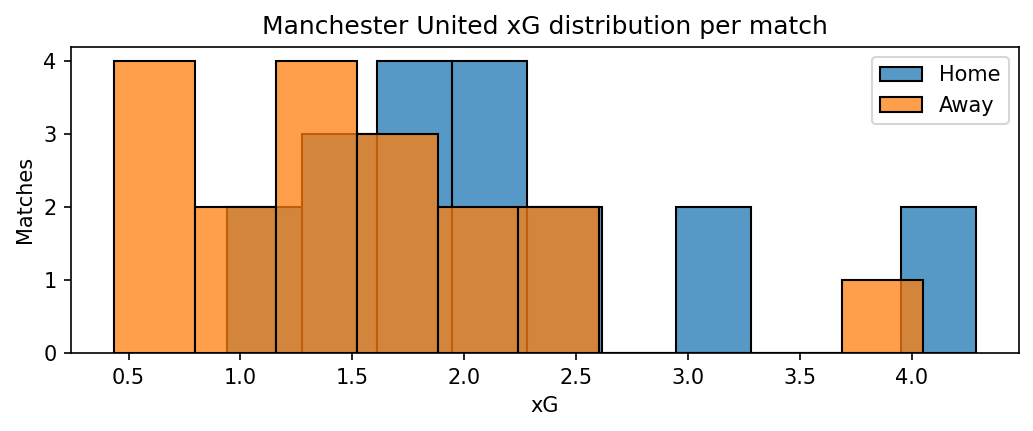

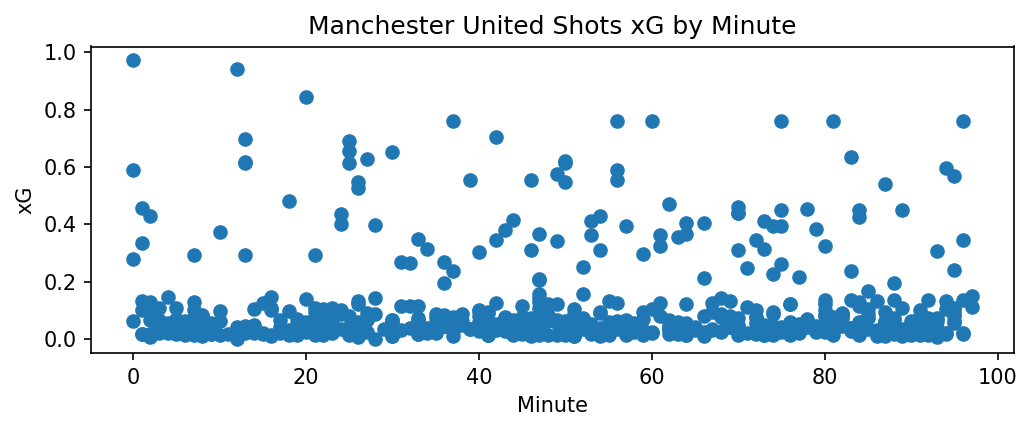

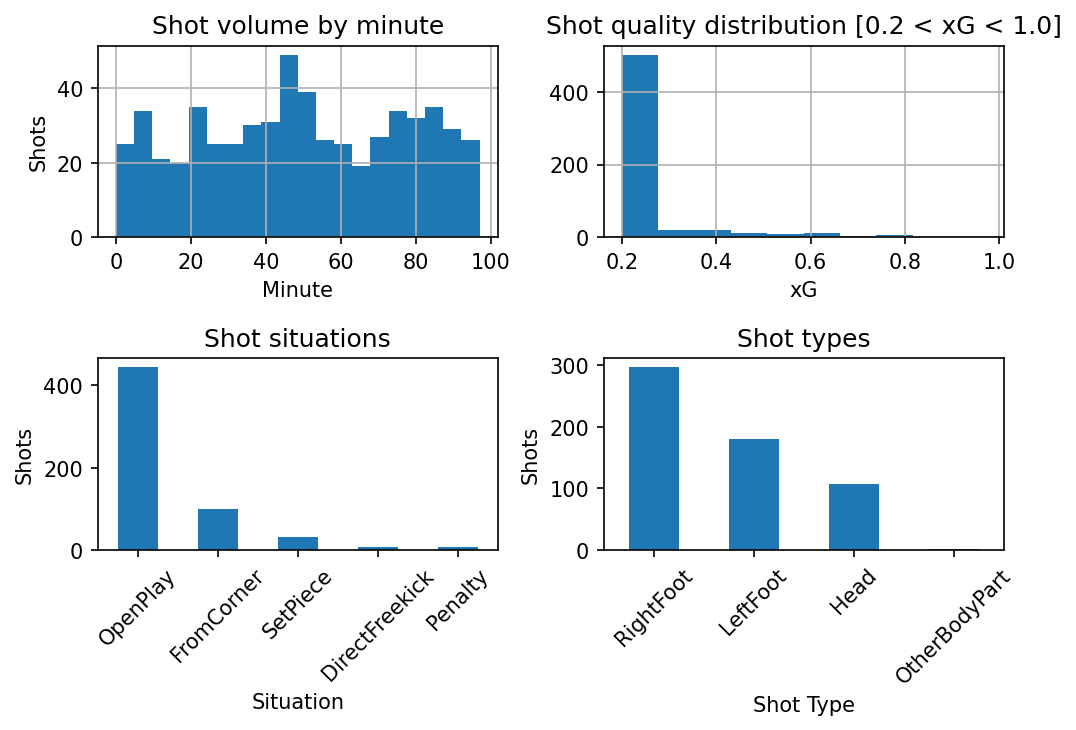

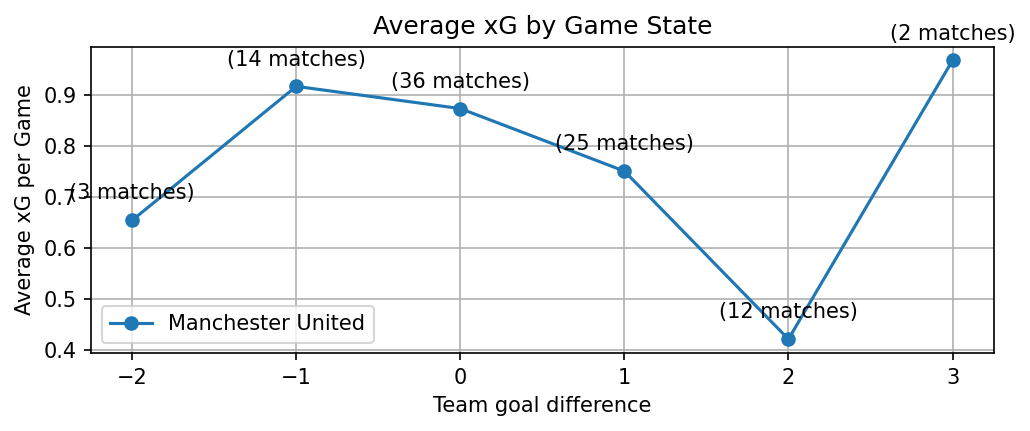

In [14]:
# Save the EDA plots
display(Image(filename=f"{PLOT_DIR}manchester_united_xg_distribution.png"))
display(Image(filename=f"{PLOT_DIR}manchester_united_shot_xg.png"))
display(Image(filename=f"{PLOT_DIR}manchester_united_shot_volume_quality.png"))
display(Image(filename=f"{PLOT_DIR}manchester_united_avg_xg_by_game_state.png"))

- Import feature engineering script and load new features

In [15]:
# Import a hidden (private) function
import feature_engineering

# Use last 'rolling_window' number of games to build features
rolling_window = 10
features_df = feature_engineering.build_features(match_data, shots_data, window=rolling_window)
# print(features_df.head())

In [16]:
# Sanity check of the generated features
features_df.describe()
# features_df.head(10)


,match_id,xg_for_diff_last_10,defensive_xg_against_diff_last_10,xg_net_diff_last_10,xg_tied_diff_last_10,xg_leading_diff_last_10,xg_trailing_diff_last_10,xg_first_30_diff_last_10,xg_60_90_diff_last_10,big_chances_diff_last_10,finishing_diff_last_10,h_goals,a_goals
count,370.00000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000,370.000000
mean,28962.50000,-0.015519,-0.024848,-0.040366,-0.007764,-0.015610,0.007855,0.001702,-0.010039,-0.015262,-0.004700,1.532432,1.227027
std,106.95404,0.576079,0.511112,0.918606,0.363522,0.441515,0.304871,0.245602,0.226970,0.903793,0.539022,1.178064,1.088160
min,28778.00000,-1.287939,-1.636607,-2.623790,-1.163990,-1.670373,-0.829447,-0.788352,-0.875820,-3.000000,-3.070910,0.000000,0.000000
25%,28870.25000,-0.430437,-0.335208,-0.696217,-0.236278,-0.267469,-0.166295,-0.162239,-0.151319,-0.600000,-0.263924,1.000000,0.000000
50%,28962.50000,0.000000,-0.011879,0.000000,-0.017341,-0.014107,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,29054.75000,0.394208,0.257296,0.609586,0.236296,0.270388,0.180655,0.165124,0.141222,0.600000,0.286125,2.000000,2.000000
max,29147.00000,1.673093,1.493033,2.349427,1.429759,1.423195,1.334409,0.768721,0.830329,3.000000,1.473647,5.000000,5.000000


- Train ML Models and Predict a match outcome

In [17]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


def select_models():
    return {
        'XGBoost': xgb.XGBClassifier(
                n_estimators=250,
                learning_rate=0.03,
                max_depth=2,
                subsample=0.85,
                colsample_bytree=0.85,
                eval_metric='logloss',
                random_state=42,
            ),
        'Random_Forest': RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=5,
            class_weight='balanced_subsample',
            random_state=42,
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.04,
            max_depth=2,
            random_state=42,
        )
        # Add more models here ...
        }

FEATURE_COLUMNS = [
    f"xg_for_diff_last_{rolling_window}",
    f"defensive_xg_against_diff_last_{rolling_window}",
    f"xg_net_diff_last_{rolling_window}",
    f"xg_tied_diff_last_{rolling_window}",
    f"xg_leading_diff_last_{rolling_window}",
    f"xg_trailing_diff_last_{rolling_window}",
    f"xg_first_30_diff_last_{rolling_window}",
    f"xg_60_90_diff_last_{rolling_window}",
    f"big_chances_diff_last_{rolling_window}",
    f"finishing_diff_last_{rolling_window}",
    "h_goals",
    "a_goals"
]

X = features_df[FEATURE_COLUMNS]
y_home = features_df['h_goals']
y_away = features_df['a_goals']

features_df_sorted = features_df.sort_values("match_id").reset_index(drop=True)

split_index = int(0.90 * len(features_df_sorted))

train_df = features_df_sorted.iloc[:split_index]
test_df = features_df_sorted.iloc[split_index:]

X_train = train_df[FEATURE_COLUMNS]
X_test = test_df[FEATURE_COLUMNS]
# X_train = train_df
# X_test = train_df

y_home_train = train_df["h_goals"]
y_away_train = train_df["a_goals"]

y_home_test = test_df["h_goals"]
y_away_test = test_df["a_goals"]

# Initiate and train separate models for home and away teams
home_models = select_models()
away_models = select_models()

for name, hmodel in home_models.items():
    print(f"Training {name} for home team ...")
    hmodel.fit(X_train, y_home_train)

for name, amodel in away_models.items():
    print(f"Training {name} for away team ...")
    amodel.fit(X_train, y_away_train)


# Save the trained models to pickle files
MODELS_DIR = "models/"
os.makedirs(MODELS_DIR, exist_ok=True)

for name, hmodel in home_models.items():
    with open(f'models/home_model_{name}.pkl', 'wb') as f:
        pickle.dump(hmodel, f)

for name, amodel in away_models.items():
    with open(f'models/away_model_{name}.pkl', 'wb') as f:
        pickle.dump(amodel, f)

print("Models saved successfully.")

Training XGBoost for home team ...
Training Random_Forest for home team ...
Training Gradient Boosting for home team ...
Training XGBoost for away team ...
Training Random_Forest for away team ...
Training Gradient Boosting for away team ...
Models saved successfully.


In [18]:
# Predict on the test set
test_df = test_df.copy()

# Load the trained models
for name in home_models:
    with open(f'{MODELS_DIR}/home_model_{name}.pkl', 'rb') as f:
        home_models[name] = pickle.load(f)

for name in away_models:
    with open(f'{MODELS_DIR}/away_model_{name}.pkl', 'rb') as f:
        away_models[name] = pickle.load(f)

# Make predictions
for name, hmodel in home_models.items():
    test_df[f"home_pred_goals_{name}"] = hmodel.predict(X_test)
for name, amodel in away_models.items():
    test_df[f"away_pred_goals_{name}"] = amodel.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [35]:
# Sanity check for predicted data
# print(test_df.head(10))

- Lets look at the prediction accuracy

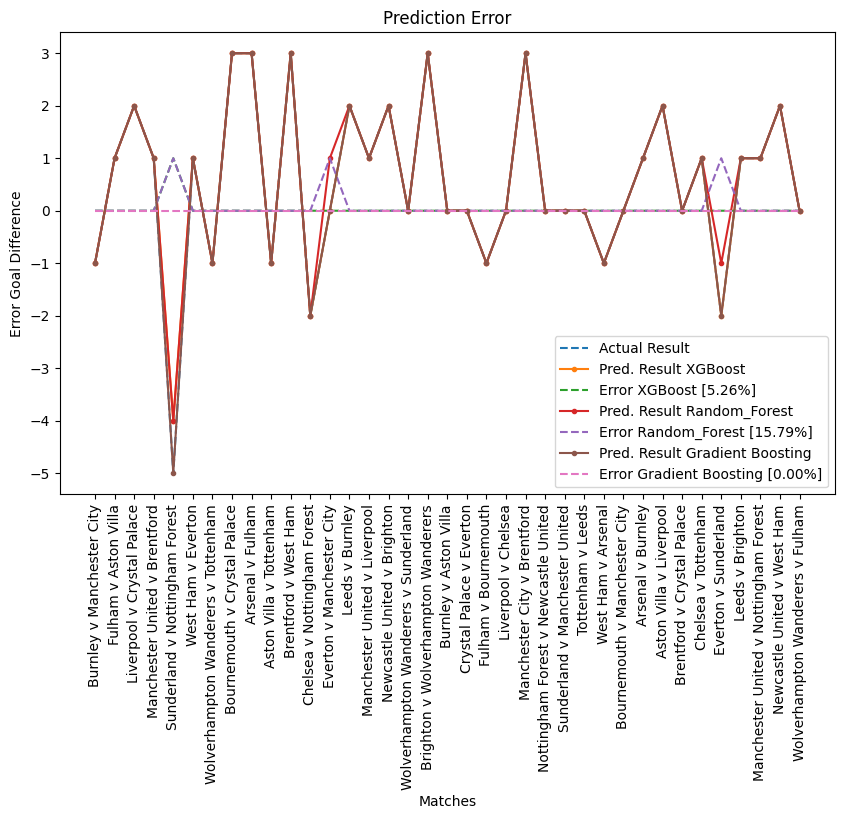

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

test_df["actual_result"] = test_df["h_goals"] - test_df["a_goals"]
test_df["match_labels"] = test_df["home_team"] + " v " + test_df["away_team"]
plt.plot(test_df["actual_result"], '--', label="Actual Result")

for name in select_models().keys():
    test_df["predicted_result"] = test_df[f"home_pred_goals_{name}"] - test_df[f"away_pred_goals_{name}"]
    test_df["error"] = (test_df["actual_result"] - test_df["predicted_result"]).abs()
    # plt.plot(test_df["h_goals"], 'go', label="Actual Home Goals")
    # plt.plot(test_df["a_goals"], 'rs', label="ActualAway Goals")
    # plt.plot(test_df["home_pred_goals"], 'bo', label="Predicted Home Goals")
    # plt.plot(test_df["away_pred_goals"], 'bs', label="Predicted Away Goals")
    # Calculate % error
    error_rate = test_df["error"].sum() / test_df["actual_result"].sum()
    plt.plot(test_df["predicted_result"], '.-', label=f"Pred. Result {name}")
    plt.plot(test_df["error"], '--', label=f"Error {name} [{error_rate:.2%}]")

ax.set_xticks(ticks=test_df.index, labels=test_df["match_labels"], rotation=90)
plt.xlabel("Matches")
plt.ylabel("Error Goal Difference")
plt.title("Prediction Error")
plt.legend()
plt.show()